<a href="https://colab.research.google.com/github/lorenzovaresio/AI_Medicine/blob/main/Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

`Progetto finale:`

### **Fase 1**: Caricamento del dataset

In [3]:
from google.colab import drive
drive.mount('/content/drive')
# After mounting, you can access your file at '/content/drive/MyDrive/HAM10000_data.pkl'

Mounted at /content/drive


Uso la libreria pandas per esplorare il dataset usando il DataFrame di Pandas:

In [9]:
import pandas as pd
import numpy as np

df = pd.read_pickle('/content/drive/MyDrive/HAM10000_data.pkl')


In [5]:
df.shape

(10015, 8)

Visualizziamo le prime 5 righe:


In [6]:
df.head(5)

,lesion_id,image_id,dx,dx_type,age,sex,localization,image
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp,"[[[190, 153, 194], [192, 154, 196], [191, 153,..."
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp,"[[[23, 13, 22], [24, 14, 24], [25, 14, 28], [3..."
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp,"[[[185, 127, 137], [189, 133, 147], [194, 136,..."
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp,"[[[24, 11, 17], [26, 13, 22], [38, 21, 32], [5..."
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear,"[[[134, 90, 113], [147, 102, 125], [159, 115, ..."


La colonna 'image' contiene delle immagini, le visualizzo utilizzando la libreria matplotlib

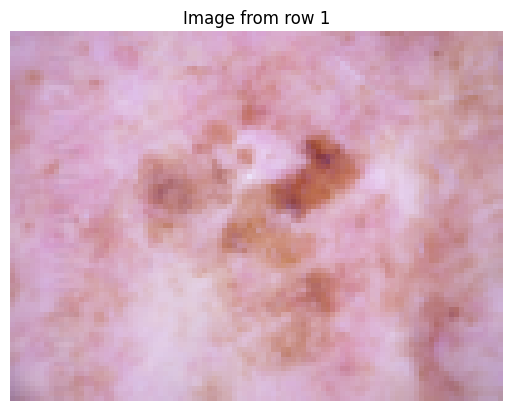

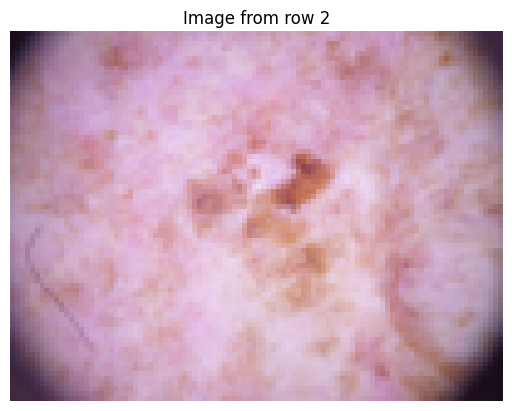

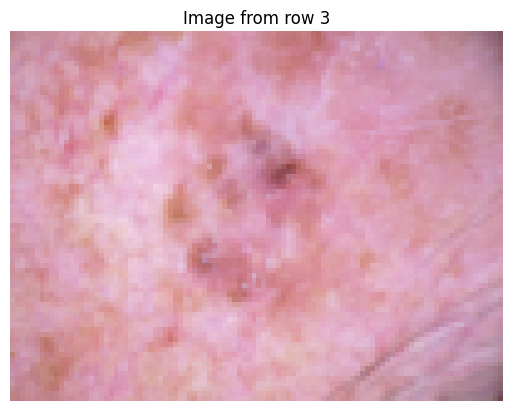

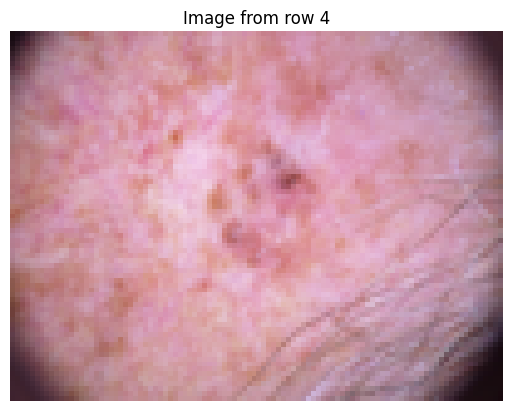

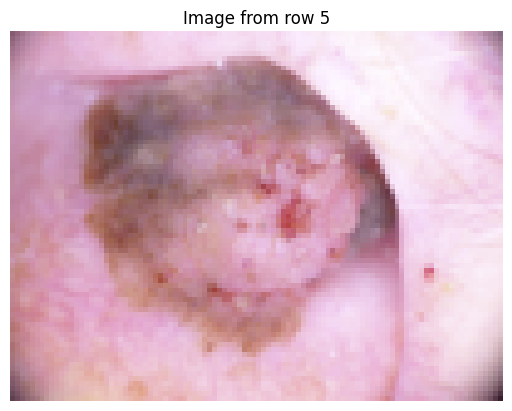

In [7]:
import matplotlib.pyplot as plt

# Visualizza le prime 5 immagini dalla colonna 'image'
for i in range(5):
    plt.imshow(df['image'].iloc[i])
    plt.title(f"Image from row {i+1}")
    plt.axis('off')
    plt.show()

Misurare correlazioni interessanti tra tutte le feature categoriche (escludendo le immagini dunque).


## Analisi a livello di Lesione

Come discusso, l'analisi precedente considerava ogni immagine come un'osservazione indipendente. Ora, raggruppiamo i dati per `lesion_id` per assicurarci che ogni lesione unica contribuisca una sola volta all'analisi delle correlazioni.

In [8]:
print("\nNumero di valori unici per 'lesion_id':")
print(df['lesion_id'].nunique())


Numero di valori unici per 'lesion_id':
7470


In [12]:
# All'età sostiuisco dei range di età
df['age_group'] = pd.cut(
    df['age'],
    bins=[0, 10, 20, 30, 40, 50, 60, 70, 80, np.inf],
    labels=['0-10', '11-20', '21-30', '31-40', '41-50', '51-60', '61-70', '71-80', '80+'],
    include_lowest=True
)


In [14]:
# Creiamo un DataFrame con una riga per ogni 'lesion_id' unico.
# Poiché 'dx', 'age_group', 'sex', e 'localization' sono unici per ogni 'lesion_id' (verificato in precedenza),
# possiamo semplicemente selezionare le colonne rilevanti e rimuovere i duplicati di 'lesion_id'.
df_lesion_level = df[['lesion_id', 'dx', 'age_group', 'sex', 'localization']].drop_duplicates(subset=['lesion_id']).copy()
df_lesione_level_2 = df['lesion_id', 'dx', 'age_group'].drop_duplicates(subset=['lesion_id']).copy()

# Ricalcoliamo i patterns a livello di lesione
patterns_lesion_dx_age_sex_localization = (
    df_lesion_level.groupby(
        ['dx', 'age_group', 'sex', 'localization'],
        observed=True
    )
    .size()
    .reset_index(name='count')
)

# Ricalcoliamo la percentuale all'interno di ogni diagnosi per i patterns a livello di lesione
patterns_lesion_dx_age_sex_localization['pct_within_dx'] = (
    patterns_lesion_dx_age_sex_localization['count']
    / patterns_lesion_dx_age_sex_localization.groupby('dx')['count'].transform('sum')
    * 100
)

print("Combinazioni uniche di (diagnosi, sesso, localizzazione ed età):")
print(patterns_lesion_dx_age_sex_localization)


Combinazioni uniche di (diagnosi, sesso, localizzazione ed età):
        dx age_group     sex     localization  count  pct_within_dx
0    akiec     21-30    male             face      1       0.438596
1    akiec     31-40  female            chest      1       0.438596
2    akiec     31-40  female             face      2       0.877193
3    akiec     31-40    male          abdomen      1       0.438596
4    akiec     31-40    male             face      1       0.438596
..     ...       ...     ...              ...    ...            ...
681   vasc     71-80    male            trunk      4       4.081633
682   vasc     71-80    male  upper extremity      1       1.020408
683   vasc       80+  female  upper extremity      1       1.020408
684   vasc       80+    male             back      1       1.020408
685   vasc       80+    male  lower extremity      1       1.020408

[686 rows x 6 columns]


In [25]:
# Ricalcoliamo il Lift per i patterns a livello di lesione

N_lesions = len(df_lesion_level)

# prevalenza generale di ogni diagnosi a livello di lesione
dx_counts_lesion = df_lesion_level['dx'].value_counts()
dx_prob_lesion = dx_counts_lesion / N_lesions


# numero totale di lesioni con ciascuna combinazione (age_group, sex, localization)
combo_counts_lesion = (
    df_lesion_level.groupby(
        ['age_group', 'sex', 'localization'],
        observed=True
    )
    .size()
)

def calculate_lift_lesion(row):
    combo = (row['age_group'], row['sex'], row['localization'])
    n_combo = combo_counts_lesion.loc[combo]

    # P(dx | combinazione) a livello di lesione
    p_dx_given_combo = row['count'] / n_combo

    # P(dx) a livello di lesione
    p_dx = dx_prob_lesion[row['dx']]

    return p_dx_given_combo / p_dx


patterns_lesion['lift'] = patterns_lesion.apply(
    calculate_lift_lesion,
    axis=1
)

print("Patterns con Lift calcolato a livello di lesione:")
print(patterns_lesion)


Patterns con Lift calcolato a livello di lesione:
        dx age_group     sex     localization  count  pct_within_dx      lift
0    akiec     21-30    male             face      1       0.438596  6.552632
1    akiec     31-40  female            chest      1       0.438596  1.927245
2    akiec     31-40  female             face      2       0.877193  2.730263
3    akiec     31-40    male          abdomen      1       0.438596  0.442745
4    akiec     31-40    male             face      1       0.438596  2.520243
..     ...       ...     ...              ...    ...            ...       ...
681   vasc     71-80    male            trunk      4       4.081633  5.081633
682   vasc     71-80    male  upper extremity      1       1.020408  1.291941
683   vasc       80+  female  upper extremity      1       1.020408  7.622449
684   vasc       80+    male             back      1       1.020408  1.814869
685   vasc       80+    male  lower extremity      1       1.020408  5.444606

[686 rows x 7

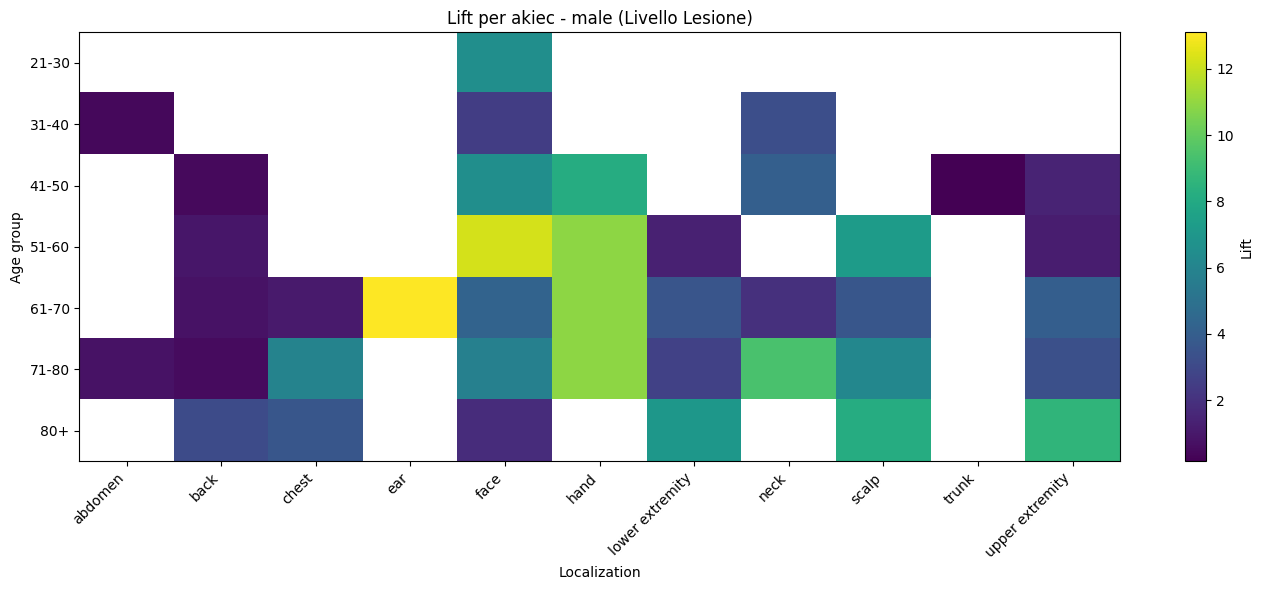

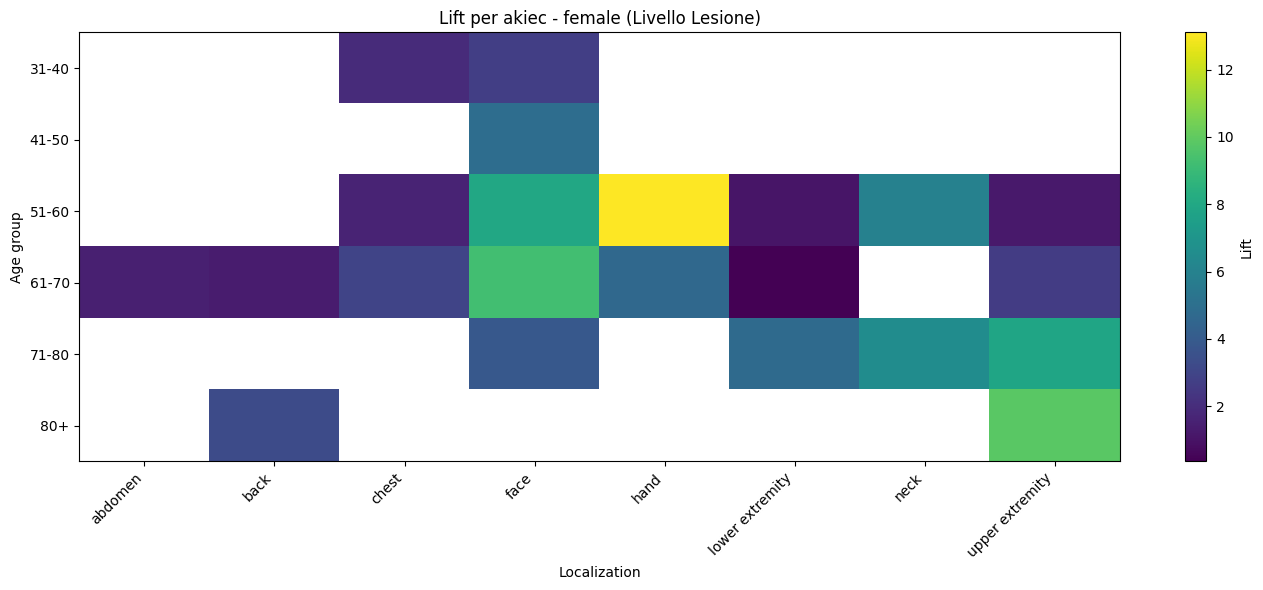

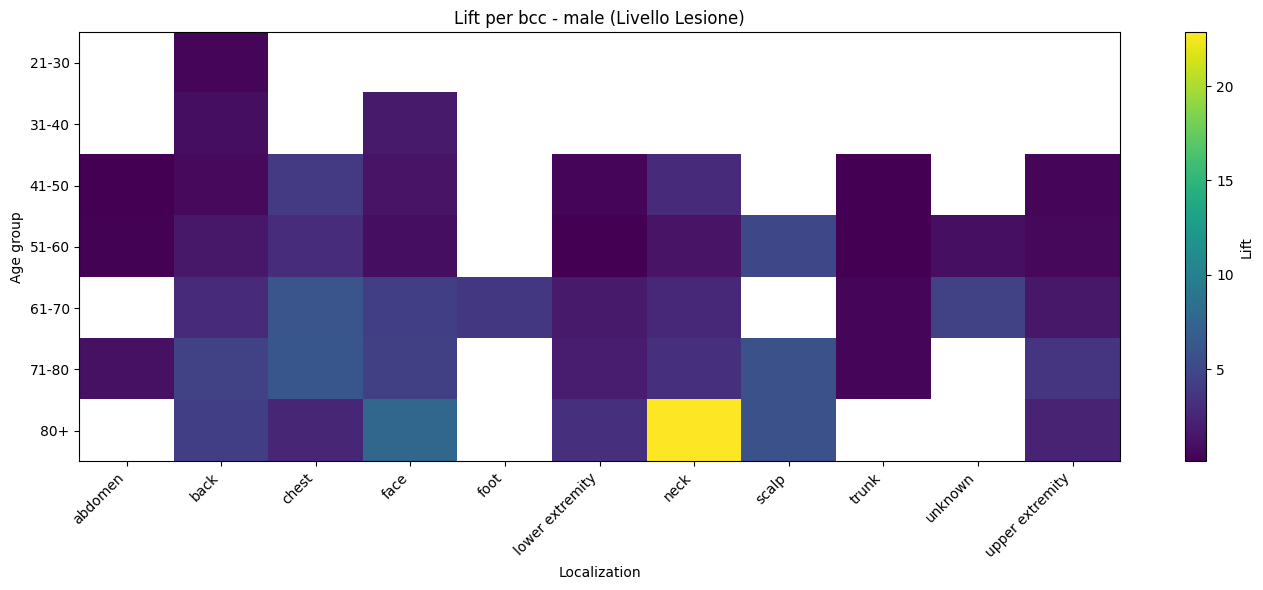

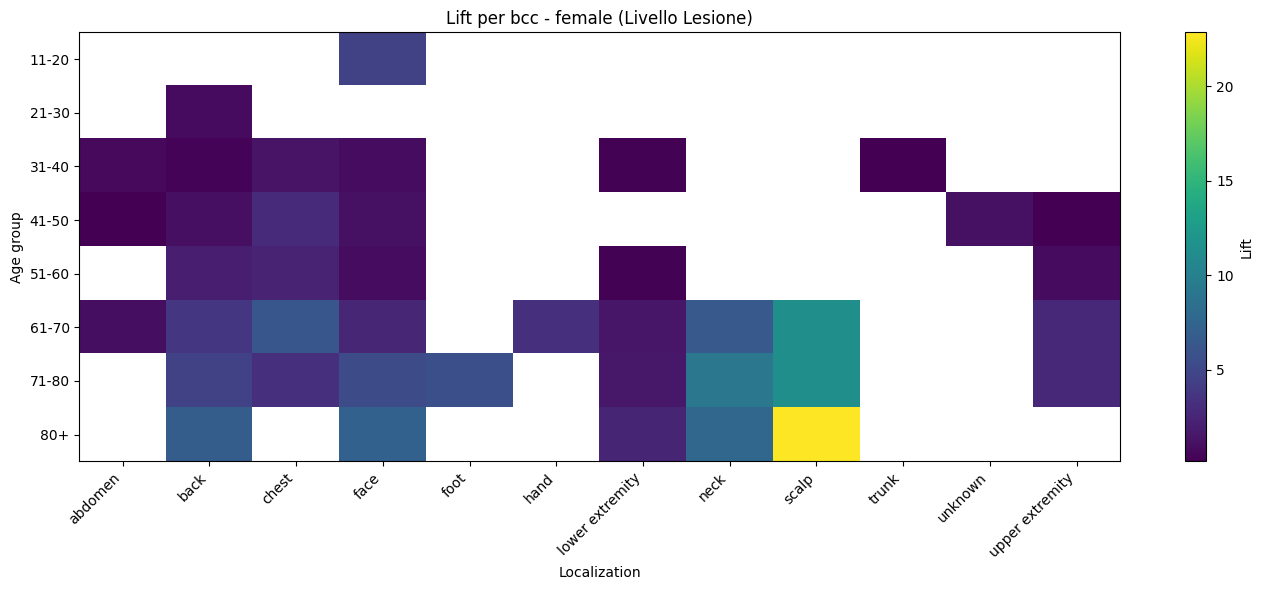

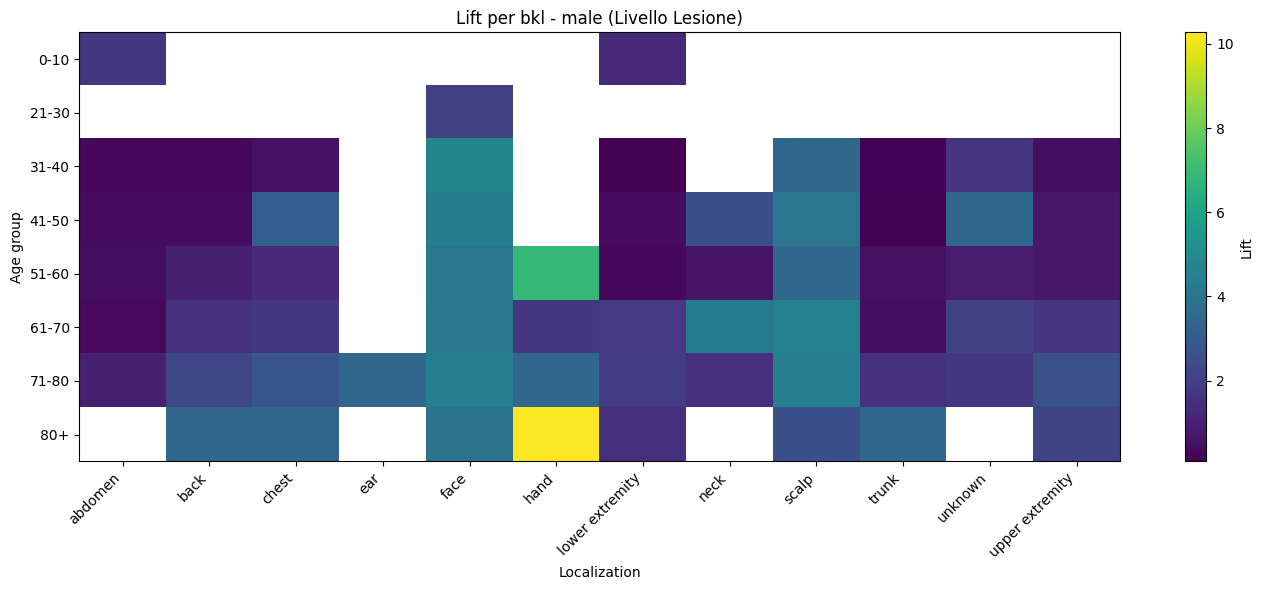

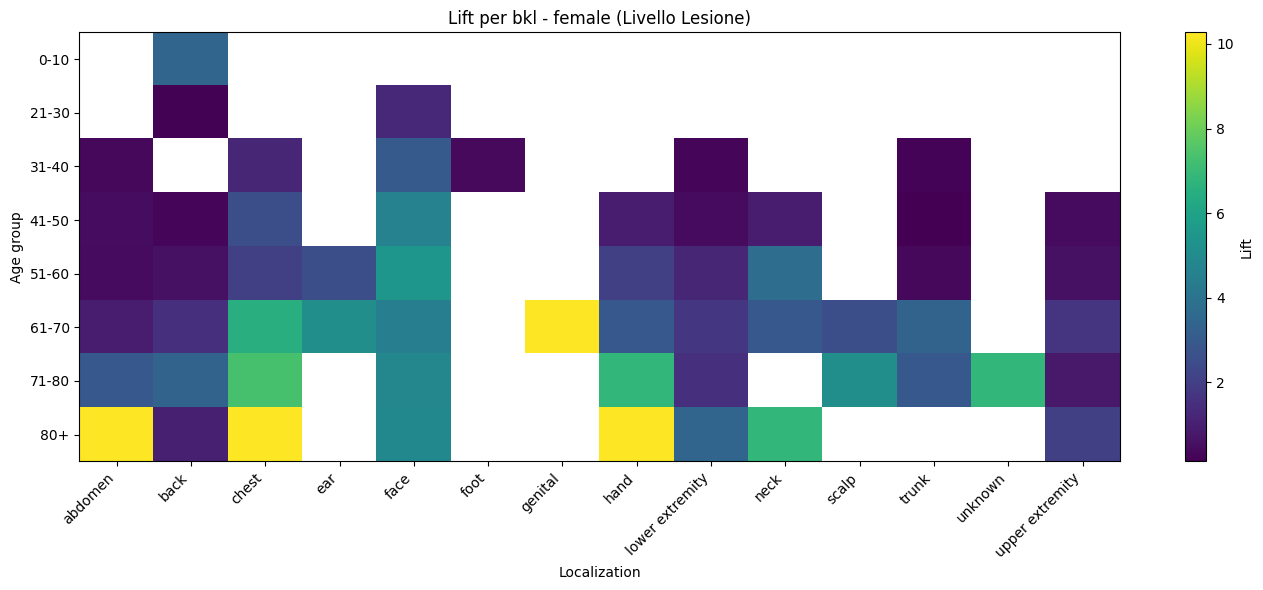

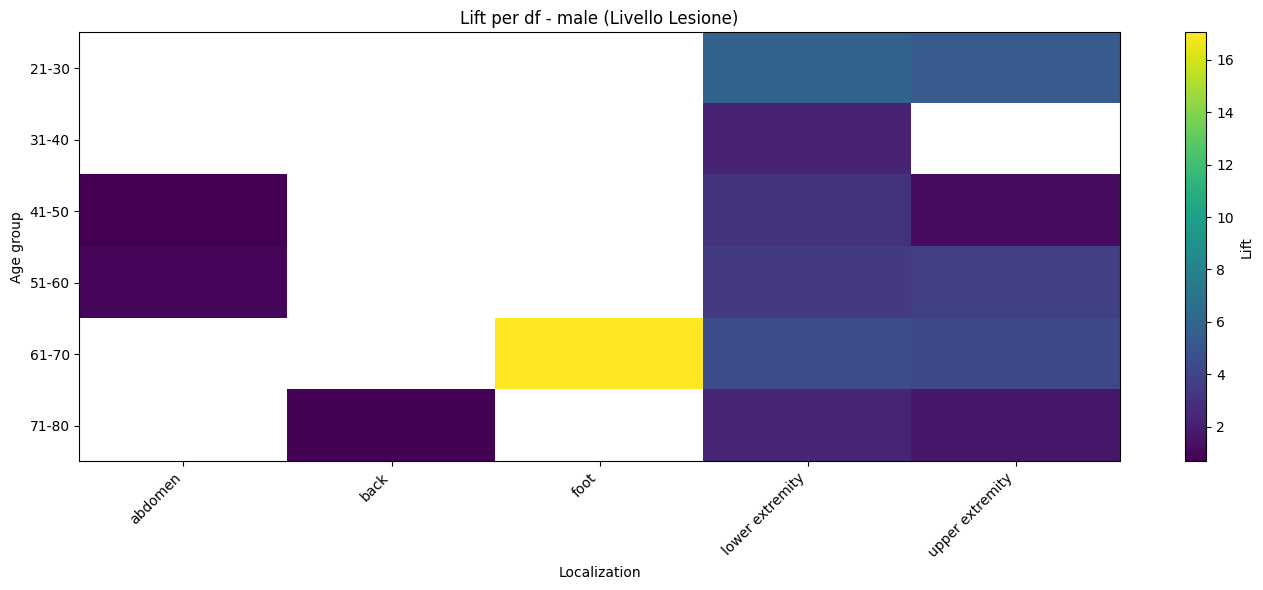

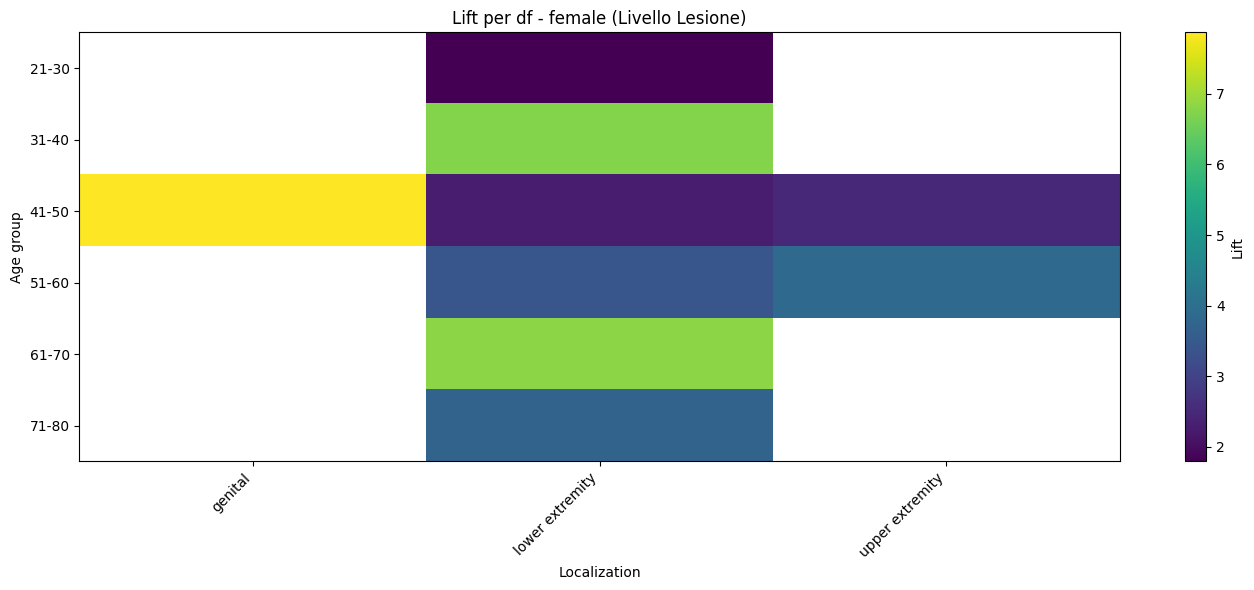

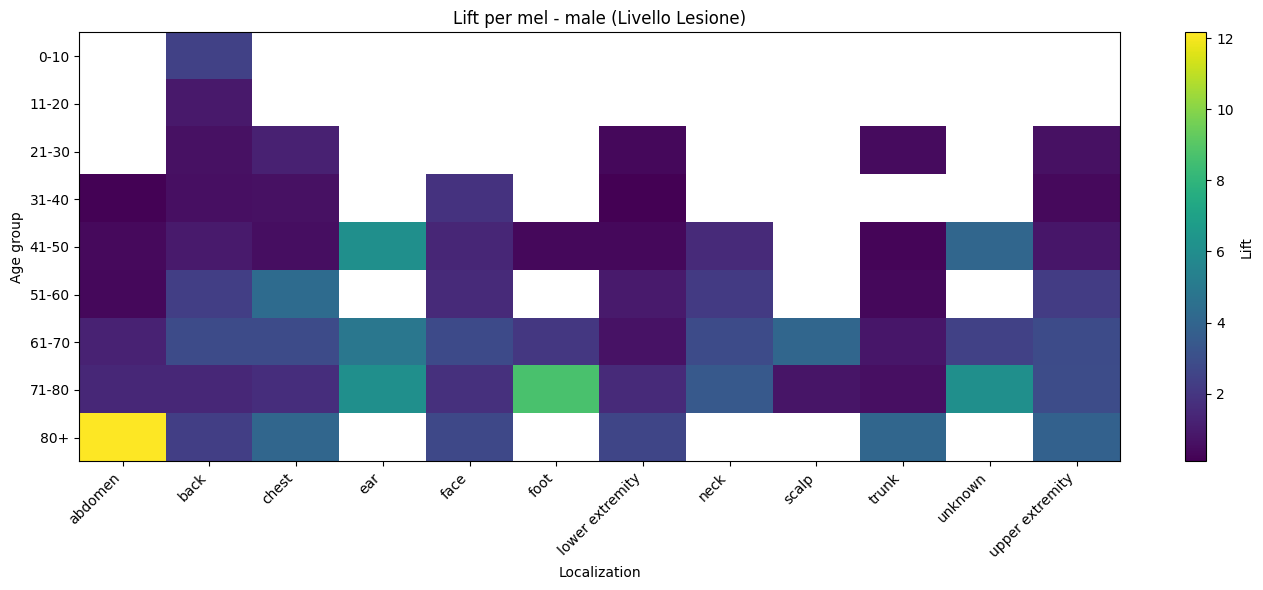

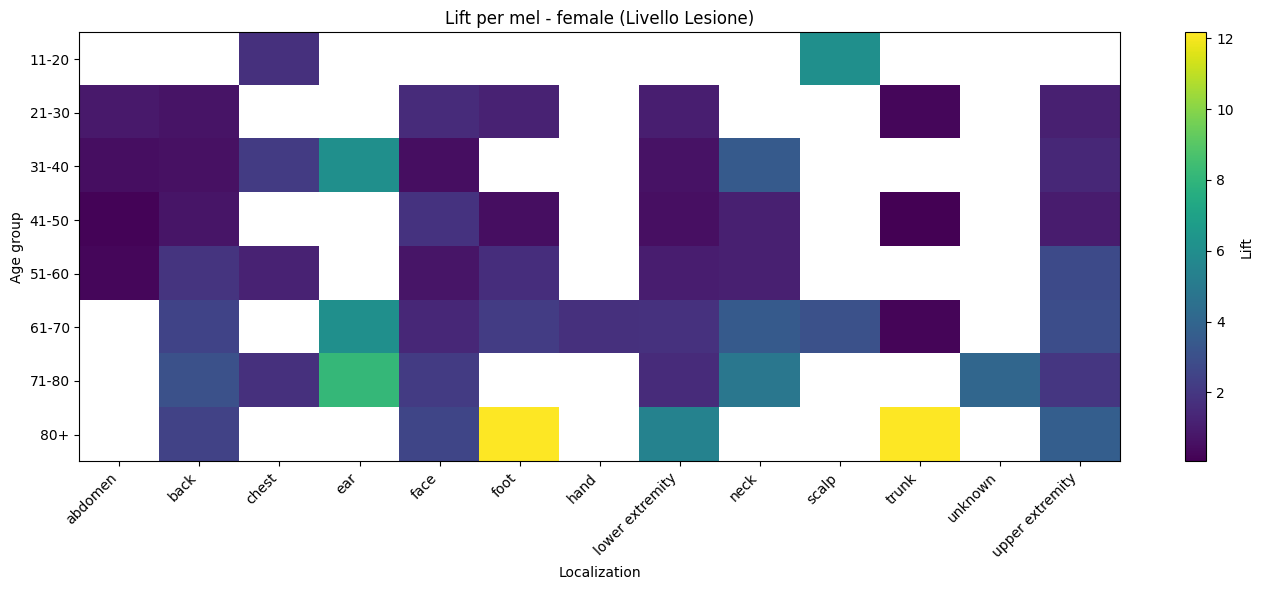

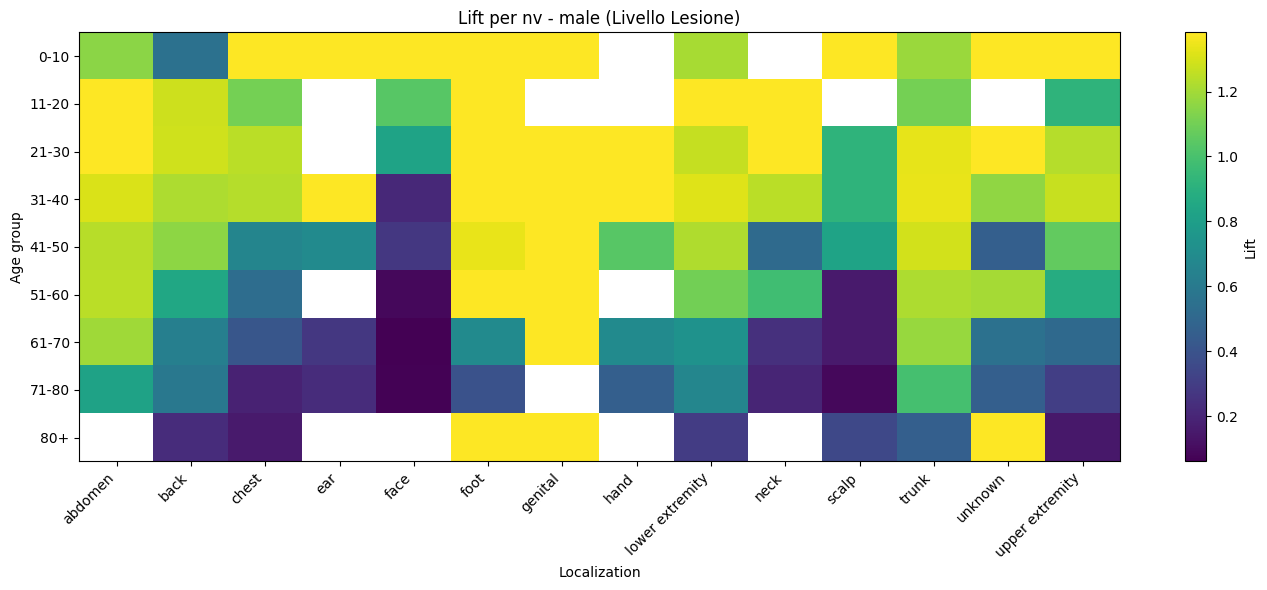

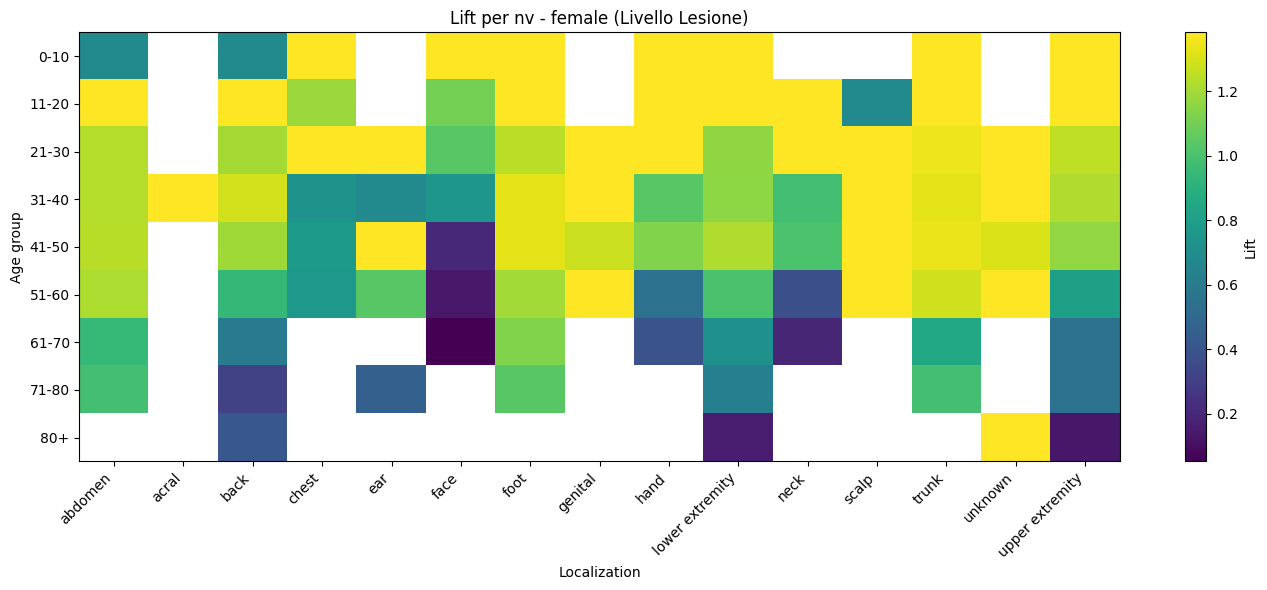

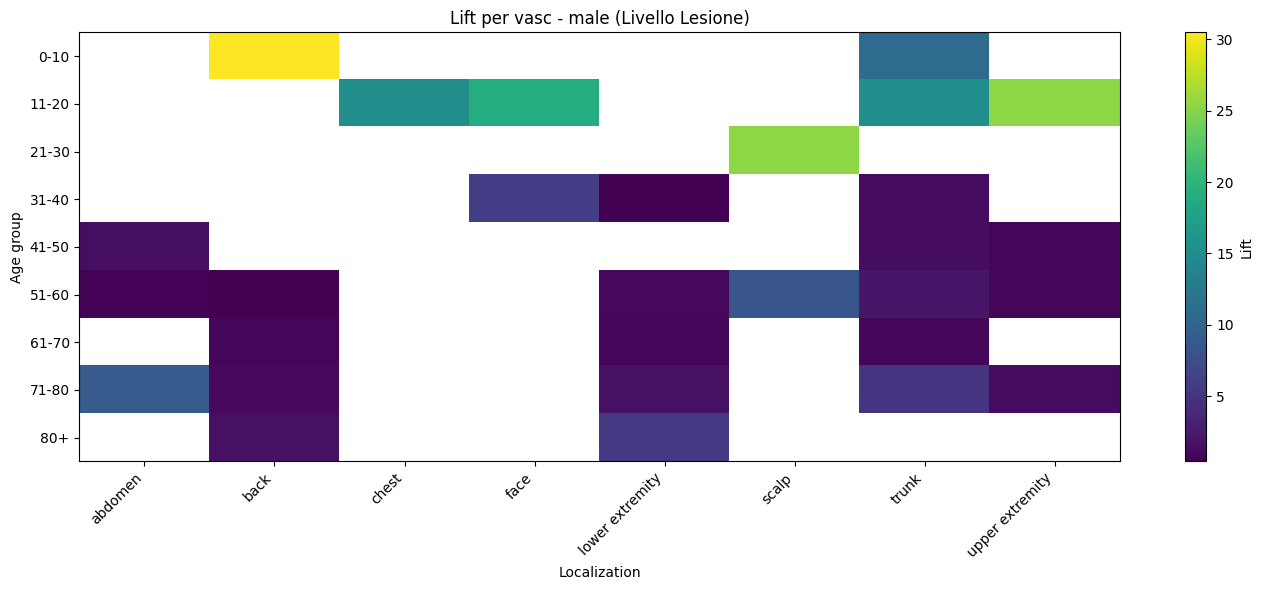

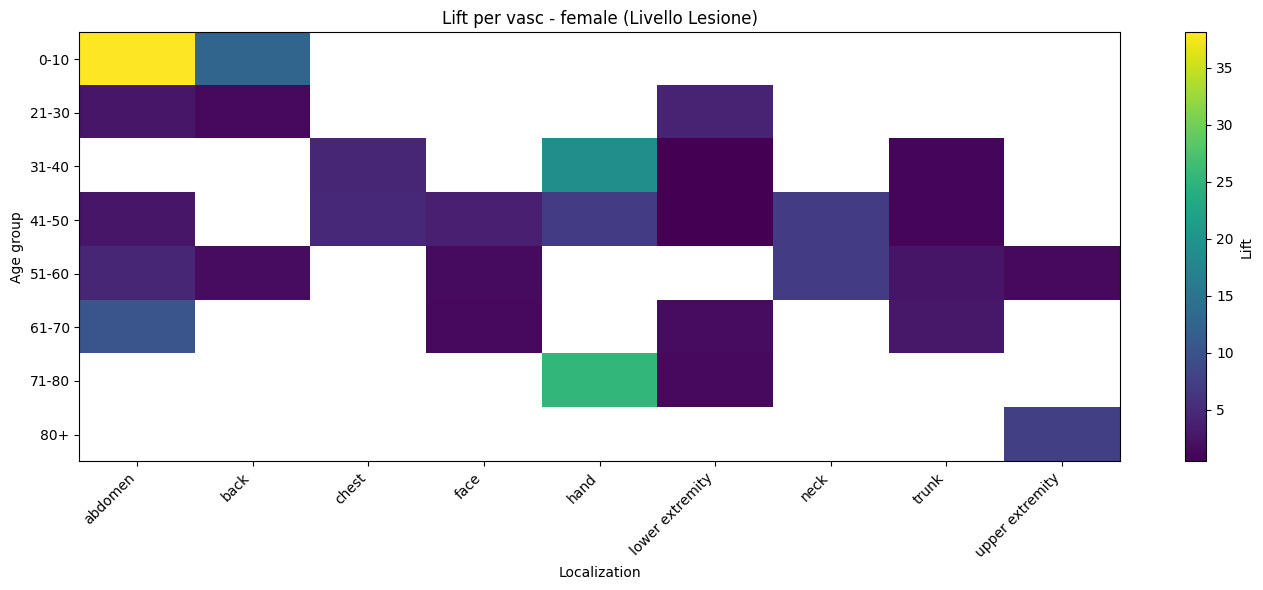

In [26]:
for dx_value in patterns_lesion['dx'].unique(): # Iterate over unique diagnosis values
  for sex in ('male', 'female'):
    les = patterns_lesion[(patterns_lesion['dx'] == dx_value) & (patterns_lesion['sex'] == sex)]

    # Ensure 'les' is not empty before pivoting
    if not les.empty:
        heatmap_data = les.pivot(index='age_group',columns='localization', values='lift')

        plt.figure(figsize=(14, 6))
        plt.imshow(
        heatmap_data,
        aspect='auto')

        plt.xticks(
        range(len(heatmap_data.columns)),
        heatmap_data.columns,
        rotation=45,
        ha='right')

        plt.yticks(range(len(heatmap_data.index)), heatmap_data.index)

        plt.colorbar(label='Lift')
        plt.title(f"Lift per {dx_value} - {sex} (Livello Lesione)") # Corrected string formatting
        plt.xlabel('Localization')
        plt.ylabel('Age group')

        plt.tight_layout()
        plt.show()
    else:
        print(f"Nessun dato per la diagnosi '{dx_value}' e sesso '{sex}' a livello di lesione.")

Ora puoi visualizzare gli heatmap del Lift utilizzando `patterns_lesion` invece di `patterns` per analizzare le correlazioni a livello di lesione.

## Capacità predittiva delle immagini rispetto alle variabili cliniche

Dopo aver analizzato la distribuzione delle variabili presenti nel dataset, vogliamo verificare
quanta informazione relativa alle caratteristiche cliniche del paziente sia contenuta direttamente
nell'immagine della lesione.

In particolare, consideriamo tre problemi di classificazione indipendenti:

- predizione della **fascia d'età**;
- predizione del **sesso**;
- predizione della **localizzazione anatomica** della lesione.

Formalmente, data un'immagine

$$
x \in \mathbb{R}^{256 \times 256 \times 3},
$$

vogliamo apprendere, per ciascuna variabile clinica $i$, una funzione

$$
f_i : \mathbb{R}^{256 \times 256 \times 3} \rightarrow \mathcal{C}_i,
$$

dove $\mathcal{C}_i$ rappresenta l'insieme delle possibili categorie associate alla variabile $i$.

In particolare:

$$
f_{\text{age}}(x) \rightarrow \mathcal{C}_{\text{age}},
$$

$$
f_{\text{sex}}(x) \rightarrow \mathcal{C}_{\text{sex}},
$$

$$
f_{\text{localization}}(x) \rightarrow \mathcal{C}_{\text{localization}}.
$$


$$
f_{\text{lesion}}(x) \rightarrow \mathcal{C}_{\text{lesion}}.
$$

L'obiettivo è quindi valutare se caratteristiche visive della lesione permettano di inferire
informazioni demografiche o anatomiche associate al paziente.

In [27]:
df.columns

Index(['lesion_id', 'image_id', 'dx', 'dx_type', 'age', 'sex', 'localization',
       'image', 'age_group'],
      dtype='object')

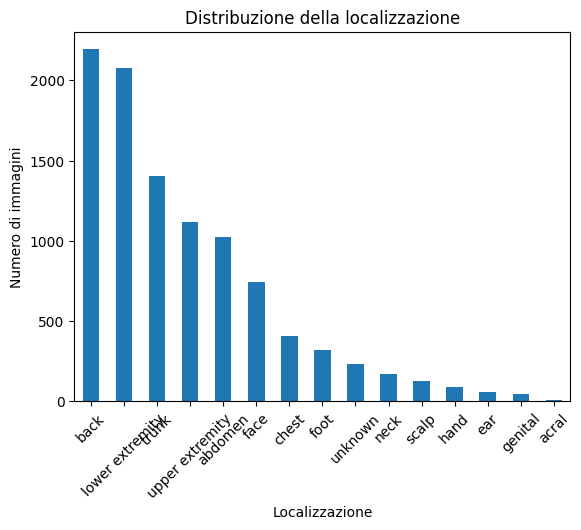

In [28]:
# @title
df.localization.value_counts(normalize = True)
df['localization'].value_counts().plot(kind='bar')

plt.title('Distribuzione della localizzazione')
plt.xlabel('Localizzazione')
plt.ylabel('Numero di immagini')
plt.xticks(rotation=45)
plt.show()


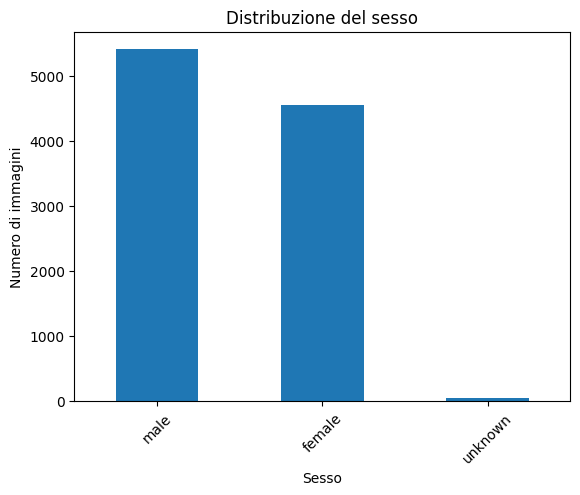

In [30]:
# @title
df.sex.value_counts(normalize = True)
df['sex'].value_counts().plot(kind='bar')

plt.title('Distribuzione del sesso')
plt.xlabel('Sesso')
plt.ylabel('Numero di immagini')
plt.xticks(rotation=45)
plt.show()

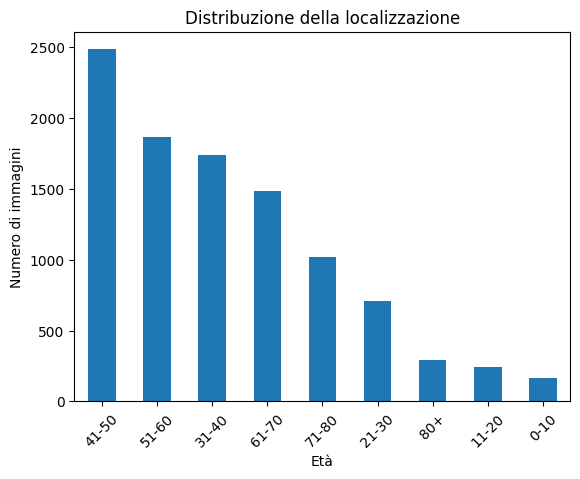

In [31]:
# @title
df.age_group.value_counts(normalize = True)
df['age_group'].value_counts().plot(kind='bar')

plt.title('Distribuzione della localizzazione')
plt.xlabel('Età')
plt.ylabel('Numero di immagini')
plt.xticks(rotation=45)
plt.show()

In [32]:
sex_given_dx = pd.crosstab(
    df['dx'],
    df['sex'],
    normalize='index'
)

sex_given_dx

sex,female,male,unknown
dx,,,
akiec,0.324159,0.675841,0.000000
bcc,0.383268,0.616732,0.000000
bkl,0.421292,0.569609,0.009099
df,0.452174,0.547826,0.000000
mel,0.380952,0.619048,0.000000
nv,0.482774,0.510216,0.007010
vasc,0.514085,0.485915,0.000000


In [33]:
sex_given_dx = pd.crosstab(
    df['dx'],
    df['localization'],
    normalize='index'
)

sex_given_dx

localization,abdomen,acral,back,chest,ear,face,foot,genital,hand,lower extremity,neck,scalp,trunk,unknown,upper extremity
dx,,,,,,,,,,,,,,,
akiec,0.015291,0.000000,0.088685,0.036697,0.009174,0.345566,0.000000,0.000000,0.039755,0.198777,0.030581,0.042813,0.003058,0.000000,0.189602
bcc,0.035019,0.000000,0.361868,0.091440,0.000000,0.196498,0.007782,0.000000,0.003891,0.112840,0.027237,0.036965,0.021401,0.009728,0.095331
bkl,0.038217,0.000000,0.183803,0.067334,0.005460,0.290264,0.000910,0.001820,0.012739,0.158326,0.028207,0.030937,0.066424,0.020928,0.094631
df,0.034783,0.000000,0.017391,0.000000,0.000000,0.000000,0.017391,0.008696,0.000000,0.713043,0.000000,0.000000,0.000000,0.000000,0.208696
mel,0.059299,0.000000,0.291105,0.061096,0.015274,0.093441,0.025157,0.000000,0.000898,0.172507,0.026056,0.012579,0.042228,0.008985,0.191375
nv,0.128262,0.001044,0.212826,0.029828,0.004474,0.014914,0.042356,0.006711,0.008203,0.220582,0.012081,0.006711,0.185086,0.029232,0.097688
vasc,0.190141,0.000000,0.154930,0.042254,0.000000,0.056338,0.000000,0.000000,0.035211,0.190141,0.021127,0.014085,0.218310,0.000000,0.077465


In [34]:
sex_given_dx = pd.crosstab(
    df['dx'],
    df['age_group'],
    normalize='index'
)

sex_given_dx

age_group,0-10,11-20,21-30,31-40,41-50,51-60,61-70,71-80,80+
dx,,,,,,,,,
akiec,0.000000,0.000000,0.003058,0.027523,0.088685,0.259939,0.287462,0.256881,0.076453
bcc,0.000000,0.001946,0.013619,0.054475,0.103113,0.116732,0.319066,0.289883,0.101167
bkl,0.005460,0.000000,0.005460,0.063694,0.132848,0.214741,0.264786,0.228389,0.084622
df,0.000000,0.000000,0.052174,0.182609,0.278261,0.191304,0.191304,0.104348,0.000000
mel,0.000898,0.005391,0.044924,0.076370,0.152740,0.224618,0.268643,0.158131,0.068284
nv,0.022371,0.034452,0.094109,0.225802,0.302461,0.176734,0.089336,0.048919,0.005817
vasc,0.063380,0.056338,0.070423,0.077465,0.197183,0.218310,0.126761,0.154930,0.035211


Il modello: algoritmi per la forward

In [35]:


def normalizza(mat):

    normalized_mat = np.copy(mat).astype(np.float32)

    num_channels = mat.shape[-1]

    mean = np.zeros(num_channels)
    var = np.zeros(num_channels)

    for c in range(num_channels):

        channel_data = mat[..., c]

        mean[c] = np.mean(channel_data)
        var[c] = np.var(channel_data)

        std_c = np.sqrt(var[c] + 1e-8)

        normalized_mat[..., c] = (
            channel_data - mean[c]
        ) / std_c

    return normalized_mat, mean, var

def trasformazione_1(w, b, data):

    fH, fW, C_in, C_out = w.shape

    # Crea tutte le finestre fH x fW dell'input contemporaneamente
    patches = np.lib.stride_tricks.sliding_window_view(
        data,
        (fH, fW),
        axis=(0, 1)
    )

    # sliding_window_view produce:
    # (out_H, out_W, C_in, fH, fW)
    #
    # vogliamo:
    # (out_H, out_W, fH, fW, C_in)

    patches = np.moveaxis(patches, 2, -1)

    # Convoluzione:
    # patches: (Hout, Wout, fH, fW, Cin)
    # w:       (fH,   fW,   Cin, Cout)
    #
    # risultato:
    # (Hout, Wout, Cout)

    output = np.einsum(
        'ijabc,abck->ijk',
        patches,
        w
    )

    # Bias broadcastato su H e W
    output += b

    return output

def ReLu(x):
  return np.maximum(0, x) # Standard ReLU takes one input and returns max(0, x)

def Max_Pooling(mat):
  # Assuming mat is (H, W, C)
  H, W, C = mat.shape
  # Calculate output dimensions for 2x2 pooling with stride 2
  out_H = H // 2
  out_W = W // 2

  pooled_mat = np.zeros((out_H, out_W, C), dtype=mat.dtype)

  for c in range(C):
    for i in range(out_H):
      for j in range(out_W):
        # Define the 2x2 window in the input 'mat'
        window = mat[2*i : 2*i + 2, 2*j : 2*j + 2, c]
        pooled_mat[i, j, c] = np.max(window)

  return pooled_mat

def CNN_Model_Homemade_Layer(image_input, W, b, gamma, beta, n_k):
  # Layer 1 parameters (randomly initialized)
  # W_1: (filter_H, filter_W, input_channels, output_channels)
  data_pad = np.pad(image_input, ((1, 1), (1, 1), (0, 0)), mode = 'constant', constant_values=0)

  # Apply convolution-like transformation
  u = trasformazione_1(W, b, data_pad)

  # Apply normalization (channel-wise)
  u_normalized, mean, standard_dev = normalizza(u)

  # Apply scaling and shifting (similar to Batch Normalization)
  v = gamma * u_normalized + beta

  # Apply ReLU activation
  r = ReLu(v)

  # Apply Max Pooling
  h = Max_Pooling(r)
  cache = {
      "image_input": image_input,
      "data_pad": data_pad,
      "u": u,
      "u_normalized": u_normalized,
      "mean": mean,
      "var": standard_dev,
      "v": v,
      "r": r
  }

  return cache, h # Return the output of the first layer



# The variable `image_try` was not assigned in the original cell.
# It will be defined in a separate execution cell for demonstration.

In [36]:
def Global_Average_Pooling(mat):

  H, W, C = mat.shape
  vec_out = np.zeros(C)
  somma = 0



  for k in range(0, C):
    for i in range(0, H):
      for j in range(0, W):
          somma = somma + mat[i, j, k]

    vec_out[k] = somma

  return vec_out




In [37]:
def SoftMax(vect, W, b):
  l = vect.shape[0]
  y = np.zeros(l)

  z = W @ vect + b

  z_norm = z - np.max(z)

  den = np.sum(np.exp(z_norm))
  y = np.exp(z_norm) / den

  return z, y



In [38]:
Inizializzazione dei pesi

SyntaxError: invalid syntax (4078521299.py, line 1)

In [45]:
W = [np.random.randn(3, 3, 3, 32),
     np.random.randn(3, 3, 32, 64),
     np.random.randn(3, 3, 64, 128),
     np.random.randn(3, 3, 128, 256),
     np.random.randn(7, 256)]

b = [np.zeros(32),
     np.zeros(64),
     np.zeros(128),
     np.zeros(256),
     np.zeros(7)]

gamma = [np.ones(32),
         np.ones(64),
         np.ones(128),
         np.ones(256)]

beta = [np.zeros(32),
         np.zeros(64),
         np.zeros(128),
         np.zeros(256)]

### Esempio di utilizzo di `CNN_Model_Homemade`

Creiamo un'immagine di input fittizia e la passiamo attraverso il `CNN_Model_Homemade` per vedere l'output del primo strato.

In [46]:
import numpy as np
import pandas as pd # Import pandas





# Carica la prima immagine dal DataFrame df
image_try = df['image'].iloc[0]

print(f"Forma dell'input: {image_try.shape}")

# Esegui il primo strato della CNN fatta in casa
cache1, h1 = CNN_Model_Homemade_Layer(image_try, W[0], b[0], gamma[0], beta[0], 32)

print(f"Forma dell'output del primo strato: {h1.shape}")

cache2, h2 = CNN_Model_Homemade_Layer(h1, W[1], b[1], gamma[1], beta[1], 64)

print(f"Forma dell'output del secondo strato: {h2.shape}")

cache3, h3 = CNN_Model_Homemade_Layer(h2, W[2], b[2], gamma[2], beta[2], 128)

print(f"Forma dell'output del terzo strato: {h3.shape}")

cache4, h4 = CNN_Model_Homemade_Layer(h3, W[3], b[3], gamma[3], beta[3], 256)

print(f"Forma dell'output del quarto strato: {h4.shape}")

layer_GAP = Global_Average_Pooling(h4)

print(f"Forma dell'output dopo GAP: {layer_GAP.shape[0]}")

z, output_layer = SoftMax(layer_GAP, W[4], b[4])

print(f"Forma dell'output finale: {output_layer.shape[0]}")

Forma dell'input: (75, 100, 3)
Forma dell'output del primo strato: (37, 50, 32)
Forma dell'output del secondo strato: (18, 25, 64)
Forma dell'output del terzo strato: (9, 12, 128)
Forma dell'output del quarto strato: (4, 6, 256)
Forma dell'output dopo GAP: 256
Forma dell'output finale: 7


Training:
- Scelgo come Loss la cross entropy

In [49]:
def CrossEntropy(y_true, prediction):
  eps = 1e-12
  CrossEntropy = - np.sum(y_true * np.log(prediction + eps))
  return CrossEntropy

learning_rate = 0.02

def Conv_Block_Backward(d_next, cache, W, b, beta, gamma):

    data_pad = cache["data_pad"]
    u = cache["u"]
    u_normalized = cache["u_normalized"]
    mean = cache["mean"]
    var = cache["var"]
    v = cache["v"]
    r = cache["r"]

    eps = 1e-8

    # ============================================================
    # 1. MAX POOLING BACKWARD
    # ============================================================

    dr = np.zeros_like(r, dtype=np.float64)

    H_out, W_out, C = d_next.shape

    for i in range(H_out):
        for j in range(W_out):

            # tutte le feature maps contemporaneamente
            window = r[
                2*i:2*i+2,
                2*j:2*j+2,
                :
            ]                                  # (2, 2, C)

            # appiattisco solo le dimensioni spaziali
            flat = window.reshape(4, C)

            max_pos = np.argmax(flat, axis=0)   # (C,)

            row = max_pos // 2
            col = max_pos % 2

            channels = np.arange(C)

            dr[
                2*i + row,
                2*j + col,
                channels
            ] += d_next[i, j, :]


    # ============================================================
    # 2. RELU BACKWARD
    # ============================================================

    dv = dr * (v > 0)


    # ============================================================
    # 3. GAMMA / BETA BACKWARD
    # ============================================================

    dgamma = np.sum(
        dv * u_normalized,
        axis=(0, 1)
    )

    dbeta = np.sum(
        dv,
        axis=(0, 1)
    )

    du_normalized = dv * gamma


    # ============================================================
    # 4. NORMALIZZAZIONE BACKWARD
    # ============================================================

    H, W_u, C = u.shape

    N = H * W_u

    inv_std = 1.0 / np.sqrt(var + eps)          # (C,)

    sum_dx = np.sum(
        du_normalized,
        axis=(0, 1)
    )                                           # (C,)

    sum_dx_xhat = np.sum(
        du_normalized * u_normalized,
        axis=(0, 1)
    )                                           # (C,)

    du = (
        inv_std / N
    ) * (
        N * du_normalized
        - sum_dx
        - u_normalized * sum_dx_xhat
    )


    # ============================================================
    # 5. CONVOLUTION BACKWARD
    # ============================================================

    kernel_H, kernel_W, C_in, C_out = W.shape

    H_u, W_u, _ = du.shape

    # Bias
    db = np.sum(
        du,
        axis=(0, 1)
    )


    # ------------------------------------------------------------
    # dW
    # ------------------------------------------------------------

    patches = np.lib.stride_tricks.sliding_window_view(
        data_pad,
        (kernel_H, kernel_W),
        axis=(0, 1)
    )

    # shape iniziale:
    # (H_u, W_u, C_in, kernel_H, kernel_W)

    patches = np.moveaxis(
        patches,
        2,
        -1
    )

    # ora:
    # (H_u, W_u, kernel_H, kernel_W, C_in)

    dW = np.einsum(
        'ijabc,ijk->abck',
        patches,
        du
    )


    # ------------------------------------------------------------
    # ddata_pad
    # ------------------------------------------------------------

    ddata_pad = np.zeros(
        data_pad.shape,
        dtype=np.float64
    )

    # du[i,j,k] * W[a,b,c,k]
    #
    # produce:
    # (H_u, W_u, kernel_H, kernel_W, C_in)

    contributions = np.einsum(
        'ijk,abck->ijabc',
        du,
        W
    )

    # dobbiamo sommare le finestre sovrapposte
    for a in range(kernel_H):
        for bb in range(kernel_W):

            ddata_pad[
                a:a + H_u,
                bb:bb + W_u,
                :
            ] += contributions[
                :, :, a, bb, :
            ]


    # ============================================================
    # 6. RIMOZIONE DEL PADDING
    # ============================================================

    dimage_input = ddata_pad[
        1:-1,
        1:-1,
        :
    ]

    return dimage_input, dW, db, dbeta, dgamma

In [51]:
# @title
import numpy as np
import time

np.random.seed(42)

# Tutti i lesion_id distinti
lesion_ids = df["lesion_id"].unique()

# Mischia i lesion_id
np.random.shuffle(lesion_ids)

# 15% test
n_test = int(len(lesion_ids) * 0.15)

test_lesions = lesion_ids[:n_test]
train_lesions = lesion_ids[n_test:]

train_df = df[df["lesion_id"].isin(train_lesions)].reset_index(drop=True)
test_df  = df[df["lesion_id"].isin(test_lesions)].reset_index(drop=True)

classes = sorted(df["dx"].unique())

class_to_index = {
    cls: i for i, cls in enumerate(classes)
}

def one_hot(label):
    y = np.zeros(7)
    y[class_to_index[label]] = 1
    return y

num_epochs = 20
learning_rate = 0.001


for epoch in range(num_epochs):

    predicted_classes_epoch = []
    true_classes_epoch = []

    total_loss = 0
    correct = 0

    # Mischiamo il training set a ogni epoca
    train_df = train_df.sample(frac=1).reset_index(drop=True)

    for index, row in train_df.iterrows():

        # =====================================================
        # INPUT
        # =====================================================

        image = row["image"].astype(np.float64) / 255.0
        y_true = one_hot(row["dx"])
        start = time.time()
        start2= time.time()


        # =====================================================
        # FORWARD
        # =====================================================

        cache1, h1 = CNN_Model_Homemade_Layer(
            image,
            W[0],
            b[0],
            gamma[0],
            beta[0],
            32
        )

        cache2, h2 = CNN_Model_Homemade_Layer(
            h1,
            W[1],
            b[1],
            gamma[1],
            beta[1],
            64
        )

        cache3, h3 = CNN_Model_Homemade_Layer(
            h2,
            W[2],
            b[2],
            gamma[2],
            beta[2],
            128
        )

        cache4, h4 = CNN_Model_Homemade_Layer(
            h3,
            W[3],
            b[3],
            gamma[3],
            beta[3],
            256
        )

        elapsed = time.time() - start



        # =====================================================
        # GLOBAL AVERAGE POOLING
        # =====================================================

        z = np.mean(h4, axis=(0, 1))


        # =====================================================
        # CLASSIFICATORE FINALE
        # =====================================================

        o = W[4] @ z + b[4]

        # Softmax stabile
        o_shift = o - np.max(o)

        exp_o = np.exp(o_shift)

        prediction = exp_o / np.sum(exp_o)


        # =====================================================
        # LOSS
        # =====================================================

        loss = CrossEntropy(
            y_true,
            prediction
        )

        total_loss += loss


        # =====================================================
        # ACCURACY
        # =====================================================

        predicted_class = np.argmax(prediction)
        true_class = np.argmax(y_true)

        predicted_classes_epoch.append(predicted_class)
        true_classes_epoch.append(true_class)

        if predicted_class == true_class:
            correct += 1


        # =====================================================
        # BACKWARD DEL CLASSIFICATORE
        # =====================================================

        delta = prediction - y_true

        dW5 = np.outer(delta, z)

        db5 = delta

        dz = W[4].T @ delta


        # =====================================================
        # BACKWARD DEL GAP
        # =====================================================

        dh4 = (
            np.ones_like(h4)
            * dz
            / (h4.shape[0] * h4.shape[1])
        )


        # =====================================================
        # BACKWARD DEI 4 BLOCCHI
        # =====================================================

        d3, dW4, db4, dbeta4, dgamma4 = Conv_Block_Backward(
            dh4,
            cache4,
            W[3],
            b[3],
            beta[3],
            gamma[3]
        )

        d2, dW3, db3, dbeta3, dgamma3 = Conv_Block_Backward(
            d3,
            cache3,
            W[2],
            b[2],
            beta[2],
            gamma[2]
        )

        d1, dW2, db2, dbeta2, dgamma2 = Conv_Block_Backward(
            d2,
            cache2,
            W[1],
            b[1],
            beta[1],
            gamma[1]
        )

        d0, dW1, db1, dbeta1, dgamma1 = Conv_Block_Backward(
            d1,
            cache1,
            W[0],
            b[0],
            beta[0],
            gamma[0]
        )


        # =====================================================
        # RACCOLTA GRADIENTI
        # =====================================================

        dW = [
            dW1,
            dW2,
            dW3,
            dW4,
            dW5
        ]

        db = [
            db1,
            db2,
            db3,
            db4,
            db5
        ]

        dgamma = [
            dgamma1,
            dgamma2,
            dgamma3,
            dgamma4
        ]

        dbeta = [
            dbeta1,
            dbeta2,
            dbeta3,
            dbeta4
        ]


        # =====================================================
        # UPDATE
        # =====================================================

        for l in range(5):

            W[l] -= learning_rate * dW[l]
            b[l] -= learning_rate * db[l]


        for l in range(4):

            gamma[l] -= learning_rate * dgamma[l]
            beta[l] -= learning_rate * dbeta[l]

        elapsed2 = time.time() - start2

        if (index + 1) % 100 == 0:
          print(
          f"Epoch {epoch+1} - "
          f"{index+1}/{len(train_df)} immagini"
    )



    # =========================================================
    # RISULTATI EPOCA
    # =========================================================

    average_loss = total_loss / len(train_df)

    accuracy = correct / len(train_df)

    print(
        f"Epoch {epoch+1}/{num_epochs} - "
        f"Loss: {average_loss:.4f} - "
        f"Accuracy: {accuracy:.4f}"
    )




Epoch 1 - 100/8474 immagini


KeyboardInterrupt: 